# Неоднородность городов

Сравниваются однородная система и три города с различными коэффициентами
передачи. Статистика собирается отдельно для каждого города.

## Подключение проекта

In [1]:
using DrWatson
@quickactivate "AgentSIRLab"
using DataFrames
include(srcdir("experiment_tools.jl"))

summarize_groups (generic function with 1 method)

## Городские траектории

In [2]:
cases = [
    (case="однородная", beta=[0.5, 0.5, 0.5], seed=91),
    (case="неоднородная", beta=[0.22, 0.50, 0.82], seed=91),
]
city_data = DataFrame()
for case in cases
    _, rows = run_sir(Ns=[1000, 1000, 1000], β_und=case.beta,
        β_det=case.beta ./ 10, infection_period=14, detection_time=7,
        death_rate=0.02, reinfection_probability=0.1, Is=[0, 0, 3],
        migration_rates=migration_matrix(3, 0.04), seed=case.seed,
        n_steps=120, by_city=true)
    frame = DataFrame(rows)
    frame.case .= case.case
    frame.infected_fraction = frame.infected ./ max.(frame.living, 1)
    append!(city_data, frame)
end
save_frame(city_data, "sir-city-heterogeneity", "city-trajectories.csv")
summary = combine(groupby(city_data, [:case, :city]),
    :infected_fraction => maximum => :peak_fraction,
    [:infected, :time] => ((infected, time) -> time[argmax(infected)]) => :peak_day,
    :deaths => maximum => :deaths)
save_frame(summary, "sir-city-heterogeneity", "city-summary.csv")

Row,case,city,peak_fraction,peak_day,deaths
,String,Int64,Float64,Int64,Int64
1,однородная,1,1.0,13,139
2,однородная,2,1.0,17,145
3,однородная,3,1.0,18,151
4,неоднородная,1,1.0,28,140
5,неоднородная,2,1.0,32,117
6,неоднородная,3,1.0,13,143


## Отдельные кривые для городов

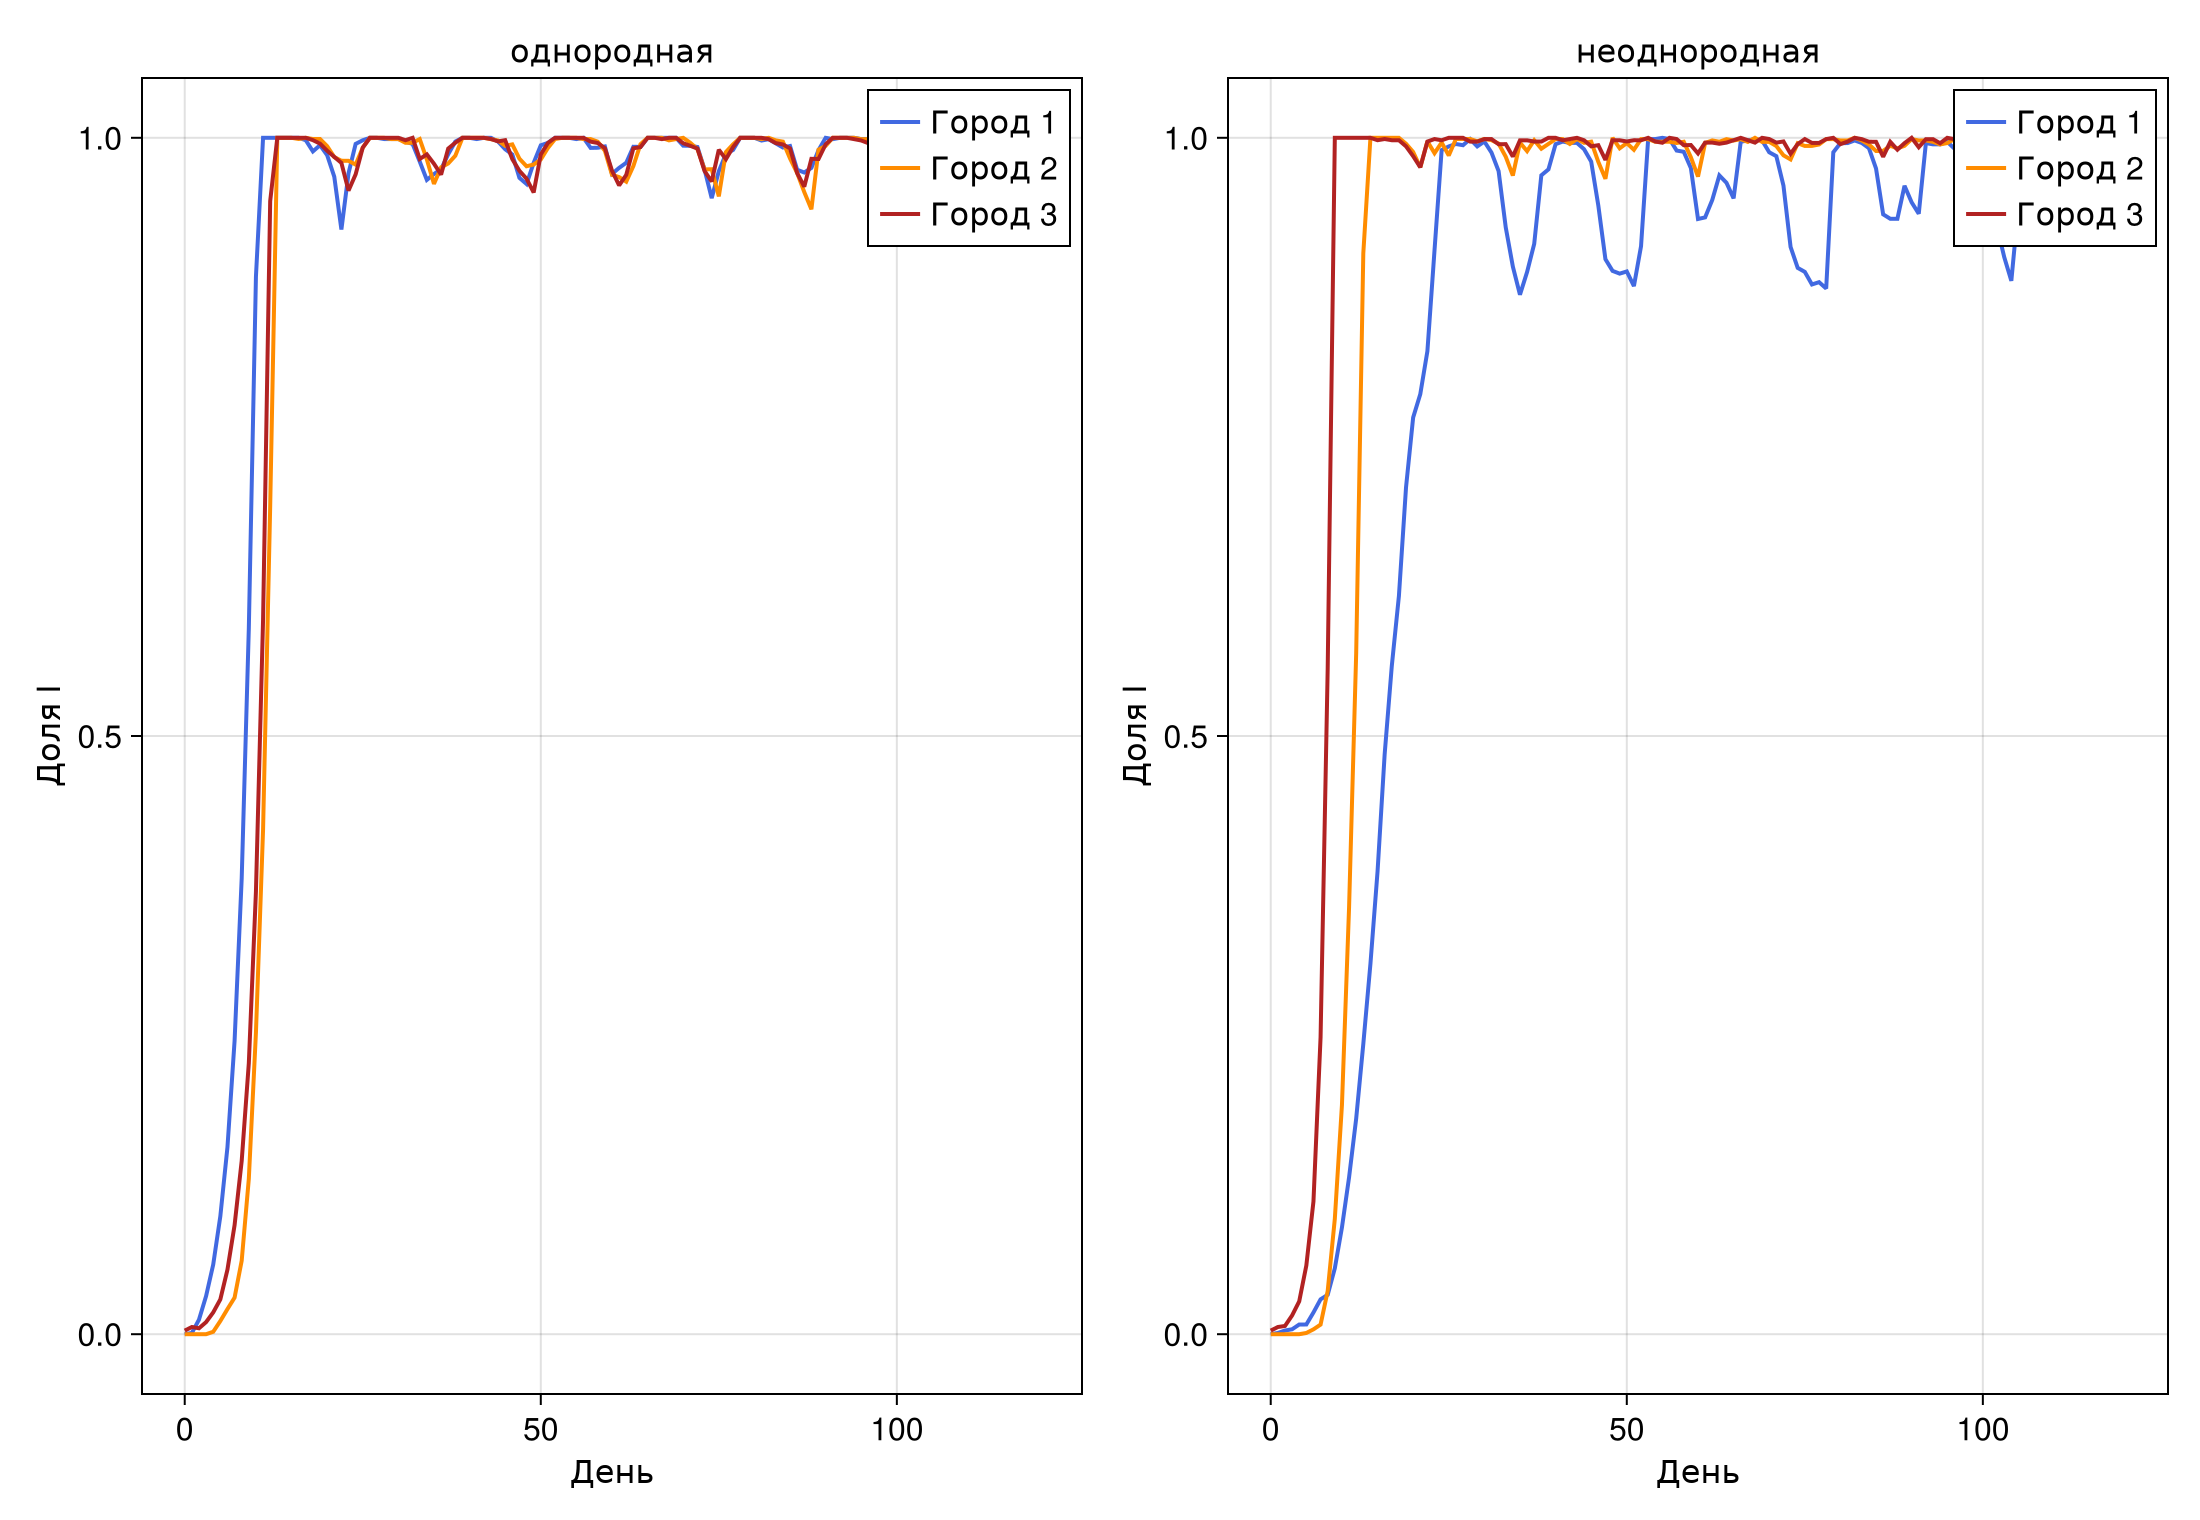

Row,case,city,peak_fraction,peak_day,deaths
,String,Int64,Float64,Int64,Int64
1,однородная,1,1.0,13,139
2,однородная,2,1.0,17,145
3,однородная,3,1.0,18,151
4,неоднородная,1,1.0,28,140
5,неоднородная,2,1.0,32,117
6,неоднородная,3,1.0,13,143


In [3]:
fig = Figure(size=(1100, 760))
for (column, case) in enumerate(cases)
    ax = Axis(fig[1, column], title=case.case, xlabel="День", ylabel="Доля I")
    for (city, colour) in zip(1:3, (:royalblue, :darkorange, :firebrick))
        subset = filter([:case, :city] => (c, n) -> c == case.case && n == city, city_data)
        lines!(ax, subset.time, subset.infected_fraction; label="Город $city", color=colour)
    end
    axislegend(ax; position=:rt)
end
save_figure(fig, "sir-city-heterogeneity", "city-heterogeneity.png";
            report_name="sir-city-heterogeneity.png")
display(fig)

comparison = Figure(size=(980, 570))
axis = Axis(comparison[1, 1], title="Дни городских пиков",
            xlabel="Город", ylabel="День пика")
for (offset, case, colour) in ((-0.16, "однородная", :royalblue),
                               (0.16, "неоднородная", :darkorange))
    subset = filter(:case => ==(case), summary)
    barplot!(axis, subset.city .+ offset, subset.peak_day;
             width=0.29, color=colour, label=case)
end
axis.xticks = (1:3, ["1", "2", "3"])
axislegend(axis; position=:lt)
save_figure(comparison, "sir-city-heterogeneity", "city-peak-days.png";
            report_name="sir-city-peak-days.png")
summary